# 逾期数据预测模块演示 (Overdue Predictor Module)

本notebook演示hscredit库中逾期数据预测模块的功能，包括：

1. **从原始数据拟合**：使用含target的数据自动分箱并提取逾期率
2. **从分箱表拟合**：使用现成的分箱统计表直接提取逾期率
3. **对无标签样本预测**：将分箱逾期率应用于新样本，计算加权逾期率
4. **系数调整功能**：设置系数调整预测偏差
5. **多标签支持**：支持多逾期标签（overdue+dpds组合）

In [1]:
# 添加项目路径
import sys
import os
sys.path.append('../')

# 初始化设置
from hscredit.utils import init_setting
init_setting(seed=42)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# 加载数据
data_path = '/Users/xiaoxi/CodeBuddy/hscredit/hscredit/examples/hscredit.xlsx'
df = pd.read_excel(data_path)
print(f"数据形状: {df.shape}")
print(f"\n列名示例: {df.columns.tolist()[:10]}...")
print(f"\n目标列分布:\n{df['FPD15'].value_counts()}")

/Users/xiaoxi/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


数据形状: (12448, 85)

列名示例: ['MOB1', 'MOB2', 'loan_date', 'bj_qy24', 'mobtech80', 'bairong_v1', 'xiaoniu_c3', 'dxm_v6pro', 'bcf_fpv1', 'apply_for_admission_confidence']...

目标列分布:
FPD15
0    11622
1      826
Name: count, dtype: int64


## 一、从原始数据拟合（单标签场景）

使用含target的数据训练预测器，自动分箱并计算各箱逾期率。

In [25]:
from hscredit.report.overdue_predictor import OverduePredictor

# 选择特征和目标
feature_col = 'bairong_v1'
target_col = 'FPD15'

# 查看特征分布
print(f"特征 {feature_col} 统计:")
print(df[feature_col].describe())
print(f"\n缺失值数量: {df[feature_col].isna().sum()}")

特征 bairong_v1 统计:
count   12448.0000
mean      758.3480
std        91.5451
min       474.0900
25%       695.4025
50%       767.1300
75%       826.9325
max       990.3400
Name: bairong_v1, dtype: float64

缺失值数量: 0


In [27]:
# 创建预测器（从原始数据拟合）
predictor = OverduePredictor(
    feature=feature_col,
    target=target_col,
    method='mdlp',
    max_n_bins=5,
    min_bin_size=0.05,
    missing_separate=True,
    desc='准入评分'
)

# 拟合
predictor.fit(df)

print("拟合完成！")
print(f"目标名称: {predictor.target_names_}")
print(f"分箱切分点: {predictor.splits_}")

拟合完成！
目标名称: ['FPD15']
分箱切分点: None


In [28]:
# 查看分箱逾期率
print("各分箱逾期率:")
for bin_label, rate in predictor.bin_rates_['_default'].items():
    if bin_label != '合计':
        print(f"  {bin_label}: {rate:.4f}")

各分箱逾期率:
  (-inf, 666.285]: 0.1240
  (666.285, 759.3349]: 0.0778
  (759.3349, 845.2649]: 0.0509
  (845.2649, +inf): 0.0231


In [29]:
# 查看分箱报告
report = predictor.get_report()
print("分箱统计报告:")
report[['指标名称', '分箱标签', '样本总数', '坏样本率']].head(10)

分箱统计报告:


,指标名称,分箱标签,样本总数,坏样本率
0,bairong_v1,"(-inf, 666.285]",2154,0.1240
1,bairong_v1,"(666.285, 759.3349]",3689,0.0778
2,bairong_v1,"(759.3349, 845.2649]",4306,0.0509
3,bairong_v1,"(845.2649, +inf)",2299,0.0231
4,bairong_v1,合计,12448,0.0664


## 二、对无标签样本进行预测

In [31]:
# 模拟无标签测试数据（从原数据抽样）
test_df = df[[feature_col]].sample(n=500, random_state=42).reset_index(drop=True)

# 进行预测
result = predictor.transform(test_df)

print("预测结果列:", result.columns.tolist())
print(f"\n预测结果前5行:")
result.head()

预测结果列: ['bairong_v1', 'bairong_v1_分箱', 'bairong_v1_基础逾期率', 'bairong_v1_预测逾期率']

预测结果前5行:


,bairong_v1,bairong_v1_分箱,bairong_v1_基础逾期率,bairong_v1_预测逾期率
0,801.7800,"(759.3349, 845.2649]",0.0509,0.0509
1,779.0500,"(759.3349, 845.2649]",0.0509,0.0509
2,674.0800,"(666.285, 759.3349]",0.0778,0.0778
3,622.5000,"(-inf, 666.285]",0.1240,0.1240
4,675.4700,"(666.285, 759.3349]",0.0778,0.0778


In [32]:
# 查看预测结果统计
print("预测逾期率分布:")
print(result[f'{feature_col}_预测逾期率'].describe())

print(f"\n分箱分布:")
print(result[f'{feature_col}_分箱'].value_counts())

预测逾期率分布:
count   500.0000
mean      0.0669
std       0.0314
min       0.0231
25%       0.0509
50%       0.0778
75%       0.0778
max       0.1240
Name: bairong_v1_预测逾期率, dtype: float64

分箱分布:
bairong_v1_分箱
(666.285, 759.3349]     171
(759.3349, 845.2649]    161
(845.2649, +inf)         88
(-inf, 666.285]          80
Name: count, dtype: int64


In [33]:
# 使用predict简化接口
predicted_rates = predictor.predict(test_df)
print(f"predict接口返回类型: {type(predicted_rates)}")
print(f"预测逾期率前5个: {predicted_rates.head().tolist()}")

predict接口返回类型: <class 'pandas.core.series.Series'>
预测逾期率前5个: [0.050859, 0.050859, 0.077799, 0.123955, 0.077799]


## 三、系数调整功能

支持三种系数设置方式：
- **float**: 统一系数，所有分箱乘以相同系数
- **dict**: 按分箱指定系数，如 `{'(-inf, 300]': 1.2, '(300, 500]': 0.9}`
- **'auto'**: 自动校正，基于整体逾期率偏差自动调整

In [34]:
# 方式1：统一系数
predictor.set_coefficients(1.2)
result_adjusted = predictor.transform(test_df)

print("统一系数调整（1.2倍）:")
print(f"  原始平均逾期率: {result[f'{feature_col}_基础逾期率'].mean():.4f}")
print(f"  调整后平均逾期率: {result_adjusted[f'{feature_col}_预测逾期率'].mean():.4f}")

统一系数调整（1.2倍）:
  原始平均逾期率: 0.0669
  调整后平均逾期率: 0.0802


In [35]:
# 方式2：按分箱指定系数
bin_labels = [k for k in predictor.bin_rates_['_default'].keys() if k not in ['合计']]
print(f"可用分箱标签: {bin_labels}")

# 为不同分箱设置不同系数（高风险分箱降低预测，低风险分箱提高预测）
if len(bin_labels) >= 2:
    coef_dict = {bin_labels[0]: 0.9}  # 第一个分箱系数0.9
    for label in bin_labels[1:]:
        coef_dict[label] = 1.1  # 其他分箱系数1.1
    
    predictor.set_coefficients(coef_dict)
    result_dict_adjusted = predictor.transform(test_df)
    
    print("\n按分箱指定系数:")
    for label, coef in coef_dict.items():
        print(f"  {label}: {coef}")
    print(f"\n调整后平均逾期率: {result_dict_adjusted[f'{feature_col}_预测逾期率'].mean():.4f}")

可用分箱标签: ['(-inf, 666.285]', '(666.285, 759.3349]', '(759.3349, 845.2649]', '(845.2649, +inf)']

按分箱指定系数:
  (-inf, 666.285]: 0.9
  (666.285, 759.3349]: 1.1
  (759.3349, 845.2649]: 1.1
  (845.2649, +inf): 1.1

调整后平均逾期率: 0.0696


In [36]:
# 查看带系数的报告
report_with_coef = predictor.get_report()
print("带调整系数的报告（前5行）:")
if '调整系数' in report_with_coef.columns:
    report_with_coef[['分箱标签', '坏样本率', '调整系数', '调整后逾期率']].head()
else:
    report_with_coef.head()

带调整系数的报告（前5行）:


## 四、从分箱表拟合

可以直接传入现成的分箱统计表进行拟合，无需原始数据。

In [37]:
# 构建人工分箱表（模拟从其他数据源获取的分箱统计）
bin_table = pd.DataFrame({
    '分箱标签': ['(-inf, 400.0]', '(400.0, 500.0]', '(500.0, 600.0]', '(600.0, +inf)', '缺失'],
    '样本总数': [1500, 3500, 4200, 3248, 0],
    '好样本数': [1275, 3220, 4032, 3182, 0],
    '坏样本数': [225, 280, 168, 66, 0],
    '坏样本率': [0.1500, 0.0800, 0.0400, 0.0203, 0.0000],
    'LIFT值': [2.27, 1.21, 0.61, 0.31, 0.00],
})

print("人工构建的分箱表:")
bin_table

人工构建的分箱表:


,分箱标签,样本总数,好样本数,坏样本数,坏样本率,LIFT值
0,"(-inf, 400.0]",1500,1275,225,0.1500,2.2700
1,"(400.0, 500.0]",3500,3220,280,0.0800,1.2100
2,"(500.0, 600.0]",4200,4032,168,0.0400,0.6100
3,"(600.0, +inf)",3248,3182,66,0.0203,0.3100
4,缺失,0,0,0,0.0000,0.0000


In [38]:
# 从分箱表创建预测器
predictor2 = OverduePredictor(feature='custom_score')
predictor2.fit(bin_table)

print("从分箱表拟合完成！")
print(f"分箱切分点: {predictor2.splits_}")
print(f"\n各分箱逾期率:")
for label, rate in predictor2.bin_rates_['_default'].items():
    print(f"  {label}: {rate:.4f}")

从分箱表拟合完成！
分箱切分点: [400. 500. 600.]

各分箱逾期率:
  (-inf, 400.0]: 0.1500
  (400.0, 500.0]: 0.0800
  (500.0, 600.0]: 0.0400
  (600.0, +inf): 0.0203
  缺失: 0.0000


In [39]:
# 生成测试数据并预测
np.random.seed(42)
test_df2 = pd.DataFrame({
    'custom_score': np.random.randn(300) * 80 + 520
})

result2 = predictor2.transform(test_df2)
print("预测结果:")
result2.head(10)

预测结果:


,custom_score,custom_score_分箱,custom_score_基础逾期率,custom_score_预测逾期率
0,559.7371,"(500.0, 600.0]",0.0400,0.0400
1,508.9389,"(500.0, 600.0]",0.0400,0.0400
2,571.8151,"(500.0, 600.0]",0.0400,0.0400
3,641.8424,"(600.0, +inf)",0.0203,0.0203
4,501.2677,"(500.0, 600.0]",0.0400,0.0400
5,501.2690,"(500.0, 600.0]",0.0400,0.0400
6,646.3370,"(600.0, +inf)",0.0203,0.0203
7,581.3948,"(500.0, 600.0]",0.0400,0.0400
8,482.4420,"(400.0, 500.0]",0.0800,0.0800
9,563.4048,"(500.0, 600.0]",0.0400,0.0400


In [40]:
# 查看分箱分布
print("分箱分布:")
print(result2['custom_score_分箱'].value_counts())

print(f"\n预测逾期率统计:")
print(result2['custom_score_预测逾期率'].describe())

分箱分布:
custom_score_分箱
(500.0, 600.0]    141
(400.0, 500.0]    104
(600.0, +inf)      39
(-inf, 400.0]      16
Name: count, dtype: int64

预测逾期率统计:
count   300.0000
mean      0.0572
std       0.0310
min       0.0203
25%       0.0400
50%       0.0400
75%       0.0800
max       0.1500
Name: custom_score_预测逾期率, dtype: float64


## 五、多标签场景（overdue + dpds）

支持同时分析多个逾期标签，如不同MOB和DPD组合。

In [41]:
# 检查可用的逾期天数列
mob_cols = [col for col in df.columns if 'MOB' in col or 'mob' in col.lower()]
print(f"可用的MOB列: {mob_cols}")

if 'MOB1' in df.columns:
    print(f"\nMOB1统计:")
    print(df['MOB1'].describe())

可用的MOB列: ['MOB1', 'MOB2', 'mobtech80']

MOB1统计:
count   12448.0000
mean        4.0794
std        15.4973
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max       106.0000
Name: MOB1, dtype: float64


In [46]:
# 多标签预测器
if 'MOB1' in df.columns:
    multi_predictor = OverduePredictor(
        feature='bairong_v1',
        overdue='MOB1',
        dpds=[7, 15, 30],  # 同时分析DPD7+、DPD15+、DPD30+
        max_n_bins=4,
        min_bin_size=0.05
    )
    
    multi_predictor.fit(df)
    
    print(f"目标标签: {multi_predictor.target_names_}")
    print(f"\n各标签逾期率:")
    for target_name, rates in multi_predictor.bin_rates_.items():
        if target_name != '_default':
            print(f"\n{target_name}:")
            for label, rate in list(rates.items())[:4]:
                if label != '合计':
                    print(f"  {label}: {rate:.4f}")

目标标签: ['MOB1_7+', 'MOB1_15+', 'MOB1_30+']

各标签逾期率:

MOB1_7+:
  (-inf, 666.285]: 0.1318
  (666.285, 759.3349]: 0.0816
  (759.3349, 845.2649]: 0.0520
  (845.2649, +inf): 0.0235

MOB1_15+:
  (-inf, 666.285]: 0.1240
  (666.285, 759.3349]: 0.0778
  (759.3349, 845.2649]: 0.0509
  (845.2649, +inf): 0.0231

MOB1_30+:
  (-inf, 666.285]: 0.1184
  (666.285, 759.3349]: 0.0740
  (759.3349, 845.2649]: 0.0488
  (845.2649, +inf): 0.0213


In [48]:
# 多标签预测
if 'MOB1' in df.columns:
    test_df_multi = df[['bairong_v1']].sample(n=200, random_state=42).reset_index(drop=True)
    
    multi_result = multi_predictor.transform(test_df_multi)
    
    print("多标签预测结果列:")
    print(multi_result.columns.tolist())
    
    print("\n预测结果（前3行）:")
    multi_result.head(3)

多标签预测结果列:
['bairong_v1', 'bairong_v1_分箱', 'bairong_v1_MOB1_7+_基础逾期率', 'bairong_v1_MOB1_7+_预测逾期率', 'bairong_v1_MOB1_15+_基础逾期率', 'bairong_v1_MOB1_15+_预测逾期率', 'bairong_v1_MOB1_30+_基础逾期率', 'bairong_v1_MOB1_30+_预测逾期率']

预测结果（前3行）:


In [57]:
# 多标签predict接口
if 'MOB1' in df.columns:
    multi_predicted = multi_predictor.predict(test_df_multi)
    
    print(f"predict返回类型: {type(multi_predicted)}")
    print(f"包含标签: {list(multi_predicted.keys())}")
    
    for target_name, rates in multi_predicted.items():
        print(f"\n{target_name}平均预测逾期率: {rates.mean():.4f}")

predict返回类型: <class 'dict'>
包含标签: ['MOB1_7+', 'MOB1_15+', 'MOB1_30+']

MOB1_7+平均预测逾期率: 0.0712

MOB1_15+平均预测逾期率: 0.0682

MOB1_30+平均预测逾期率: 0.0650


## 六、便捷函数 overdue_prediction_report

提供统一的入口函数，简化使用流程。

In [51]:
from hscredit.report.overdue_predictor import overdue_prediction_report

# 使用便捷函数（从原始数据）
train_data = df[['bairong_v1', 'FPD15']].dropna()
test_data = df[['bairong_v1']].sample(n=300, random_state=42).reset_index(drop=True)

report = overdue_prediction_report(
    train_data,
    feature='bairong_v1',
    target='FPD15',
    predict_data=test_data,
    coefficients=1.1,
    max_n_bins=5
)

print(f"报告形状: {report.shape}")
print("\n报告内容预览:")
report.head()

报告形状: (12, 24)

报告内容预览:


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,...,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值,调整系数,调整后逾期率,_section,预测逾期率
0,bairong_v1,bairong_v1,"(-inf, 666.285]",2154.0000,1887.0000,267.0000,0.1730,0.1624,0.3232,0.1240,...,0.1816,1.8680,0.1816,1887.0000,267.0000,0.1609,1.1000,0.1364,NaN,NaN
1,bairong_v1,bairong_v1,"(666.285, 759.3349]",3689.0000,3402.0000,287.0000,0.2964,0.2927,0.3475,0.0778,...,0.0726,1.4289,0.3794,5289.0000,554.0000,0.2156,1.1000,0.0856,NaN,NaN
2,bairong_v1,bairong_v1,"(759.3349, 845.2649]",4306.0000,4087.0000,219.0000,0.3459,0.3517,0.2651,0.0509,...,-0.1235,1.1478,0.6526,9376.0000,773.0000,0.1291,1.1000,0.0559,NaN,NaN
3,bairong_v1,bairong_v1,"(845.2649, +inf)",2299.0000,2246.0000,53.0000,0.1847,0.1933,0.0642,0.0231,...,-0.1478,1.0000,0.0000,11622.0000,826.0000,0.0000,1.1000,0.0254,NaN,NaN
4,bairong_v1,bairong_v1,合计,12448.0000,11622.0000,826.0000,1.0000,1.0000,1.0000,0.0664,...,1.0000,1.0000,1.0000,28174.0000,2420.0000,0.2156,1.0000,0.0000,NaN,NaN


In [56]:
# 从分箱表使用便捷函数
bin_table_for_report = pd.DataFrame({
    '分箱标签': ['(-inf, 300]', '(300, 450]', '(450, 600]', '(600, +inf)'],
    '样本总数': [1000, 3000, 5000, 3448],
    '坏样本数': [180, 240, 200, 206],
    '坏样本率': [0.1800, 0.0800, 0.0400, 0.0597],
})

test_data3 = pd.DataFrame({
    'score_v2': np.random.randn(200) * 100 + 500
})

report2 = overdue_prediction_report(
    bin_table_for_report,
    feature='score_v2',
    predict_data=test_data3,
    coefficients={'(-inf, 300]': 1.3, '(600, +inf)': 0.8}
)

print(f"报告形状: {report2.shape}")
print("\n报告内容:")
report2[['分箱标签', '坏样本率', '调整系数', '调整后逾期率']].head() if '调整系数' in report2.columns else report2.head()

报告形状: (11, 10)

报告内容:


,分箱标签,坏样本率,调整系数,调整后逾期率
0,"(-inf, 300]",0.1800,1.3000,0.2340
1,"(300, 450]",0.0800,1.0000,0.0800
2,"(450, 600]",0.0400,1.0000,0.0400
3,"(600, +inf)",0.0597,0.8000,0.0478
4,NaN,NaN,NaN,NaN


## 七、可视化分析

结合hscredit的可视化功能分析预测结果。

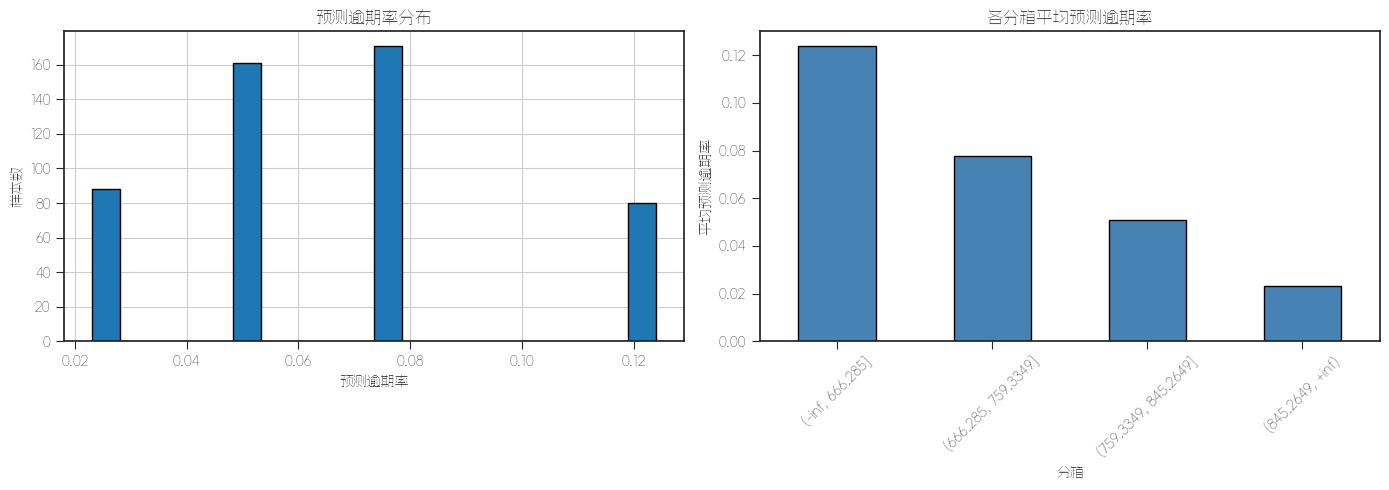

In [53]:
import matplotlib.pyplot as plt

# 恢复预测器系数为1
predictor.set_coefficients(1.0)
result_viz = predictor.transform(test_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：预测逾期率分布
ax1 = axes[0]
result_viz[f'{feature_col}_预测逾期率'].hist(bins=20, ax=ax1, edgecolor='black')
ax1.set_xlabel('预测逾期率')
ax1.set_ylabel('样本数')
ax1.set_title('预测逾期率分布')

# 右图：各分箱平均预测逾期率
ax2 = axes[1]
bin_stats = result_viz.groupby(f'{feature_col}_分箱')[f'{feature_col}_预测逾期率'].mean().sort_values(ascending=False)
bin_stats.plot(kind='bar', ax=ax2, color='steelblue', edgecolor='black')
ax2.set_xlabel('分箱')
ax2.set_ylabel('平均预测逾期率')
ax2.set_title('各分箱平均预测逾期率')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

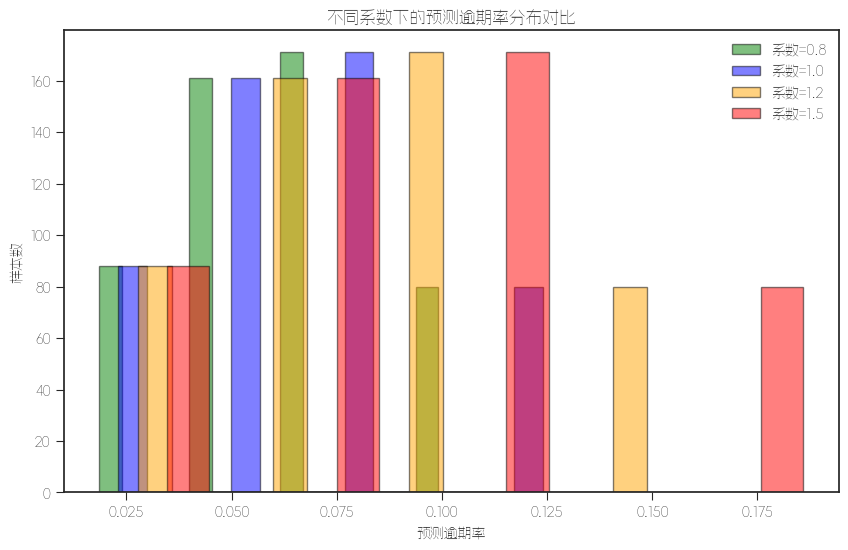

In [54]:
# 对比不同系数设置的效果
fig, ax = plt.subplots(figsize=(10, 6))

coefficients_list = [0.8, 1.0, 1.2, 1.5]
colors = ['green', 'blue', 'orange', 'red']

for coef, color in zip(coefficients_list, colors):
    predictor.set_coefficients(coef)
    temp_result = predictor.transform(test_df.copy())
    rates = temp_result[f'{feature_col}_预测逾期率']
    ax.hist(rates, bins=15, alpha=0.5, label=f'系数={coef}', color=color, edgecolor='black')

ax.set_xlabel('预测逾期率')
ax.set_ylabel('样本数')
ax.set_title('不同系数下的预测逾期率分布对比')
ax.legend()
plt.show()

## 八、完整工作流示例

展示从数据准备到预测输出的完整流程。

In [55]:
# 完整工作流
print("=== 逾期数据预测完整工作流 ===\n")

# 1. 数据准备
print("步骤1: 数据准备")
feature_name = 'loan_behavior_score'
if feature_name in df.columns:
    workflow_data = df[[feature_name, 'FPD15']].dropna()
    print(f"  使用特征: {feature_name}")
    print(f"  样本数: {len(workflow_data)}")
    print(f"  整体逾期率: {workflow_data['FPD15'].mean():.4f}\n")
    
    # 2. 划分训练集和测试集
    print("步骤2: 划分数据集")
    train_size = int(len(workflow_data) * 0.7)
    train_set = workflow_data.iloc[:train_size]
    test_set = workflow_data.iloc[train_size:][[feature_name]].reset_index(drop=True)
    print(f"  训练集: {len(train_set)} 条")
    print(f"  测试集: {len(test_set)} 条\n")
    
    # 3. 创建并训练预测器
    print("步骤3: 训练预测器")
    workflow_predictor = OverduePredictor(
        feature=feature_name,
        target='FPD15',
        max_n_bins=5,
        method='best_iv'
    )
    workflow_predictor.fit(train_set)
    print(f"  分箱数: {len(workflow_predictor.bin_rates_['_default'])}")
    print(f"  分箱切分点: {workflow_predictor.splits_}\n")
    
    # 4. 预测
    print("步骤4: 预测")
    workflow_result = workflow_predictor.transform(test_set)
    print(f"  预测完成，平均预测逾期率: {workflow_result[f'{feature_name}_预测逾期率'].mean():.4f}\n")
    
    # 5. 调整系数并重新预测
    print("步骤5: 系数调整")
    workflow_predictor.set_coefficients(1.15)
    workflow_result_adjusted = workflow_predictor.transform(test_set)
    print(f"  原始平均预测逾期率: {workflow_result[f'{feature_name}_预测逾期率'].mean():.4f}")
    print(f"  调整后平均预测逾期率: {workflow_result_adjusted[f'{feature_name}_预测逾期率'].mean():.4f}\n")
    
    # 6. 输出报告
    print("步骤6: 生成报告")
    workflow_report = workflow_predictor.get_report()
    print(f"  报告形状: {workflow_report.shape}")
    print("\n  报告预览:")
    display_cols = [c for c in ['分箱标签', '样本总数', '坏样本率', '调整系数', '调整后逾期率'] 
                    if c in workflow_report.columns]
    print(workflow_report[display_cols].head())
else:
    print(f"特征 {feature_name} 不存在于数据中")

=== 逾期数据预测完整工作流 ===

步骤1: 数据准备
  使用特征: loan_behavior_score
  样本数: 12448
  整体逾期率: 0.0664

步骤2: 划分数据集
  训练集: 8713 条
  测试集: 3735 条

步骤3: 训练预测器
  分箱数: 5
  分箱切分点: None

步骤4: 预测
  预测完成，平均预测逾期率: 0.0694

步骤5: 系数调整
  原始平均预测逾期率: 0.0694
  调整后平均预测逾期率: 0.0798

步骤6: 生成报告
  报告形状: (6, 22)

  报告预览:
               分箱标签  样本总数   坏样本率   调整系数  调整后逾期率
0    (-inf, 557.72]  1330 0.0617 1.1500  0.0709
1  (557.72, 614.98]  4173 0.0812 1.1500  0.0934
2  (614.98, 620.82]  2114 0.0464 1.1500  0.0533
3  (620.82, 646.18]   982 0.0835 1.1500  0.0960
4    (646.18, +inf)   114 0.0088 1.1500  0.0101


## 总结

本notebook演示了 `OverduePredictor` 的主要功能：

1. **灵活的数据输入**：支持从原始数据或分箱表两种模式拟合
2. **sklearn风格API**：`fit`/`transform`/`predict` 接口一致
3. **系数调整**：支持统一系数、按分箱系数、自动校正三种方式
4. **多标签支持**：支持overdue+dpds多组合分析
5. **完整报告**：提供分箱统计和预测结果报告

适用于风控场景中对无标签样本进行逾期风险预估。